<a href="https://www.kaggle.com/code/fall2fire/cardiovascular-disease-prediction-classification?scriptVersionId=306090345" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('/kaggle/input/cardiovascular-disease-risk-assessment-dataset/CVD Dataset.csv')
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


In [3]:
df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1451.000000,1448.000000,1462.000000,1465.000000,1462.000000,1456.000000,1449.000000,1462.000000,1455.000000,1450.000000,1458.000000,1447.000000,1460.000000,1459.000000
mean,47.025500,85.917427,1.754111,28.465997,91.773214,198.539148,56.197378,117.485636,175.390600,0.525727,125.627572,82.917761,111.550685,16.960925
std,12.421063,21.012580,0.113090,7.038685,12.823573,57.794099,16.066754,30.289174,11.251527,0.081213,22.112099,14.731277,58.866220,2.436192
min,25.000000,50.100000,1.502000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,-18.000000,10.530000
25%,37.000000,67.050000,1.660000,22.629000,80.500000,150.000000,42.000000,92.000000,166.000000,0.460000,107.000000,71.000000,61.000000,15.205000
50%,46.000000,86.614500,1.755000,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,109.000000,16.880000
75%,55.000000,105.000000,1.845500,34.000000,102.269000,249.000000,70.000000,138.000000,184.208500,0.583750,141.000000,93.000000,159.000000,18.630000
max,79.000000,120.000000,2.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000,24.170000


In [4]:
df.isnull().sum()

Sex                              0
Age                             78
Weight (kg)                     81
Height (m)                      67
BMI                             64
Abdominal Circumference (cm)    67
Blood Pressure (mmHg)            0
Total Cholesterol (mg/dL)       73
HDL (mg/dL)                     80
Fasting Blood Sugar (mg/dL)     67
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Family History of CVD            0
Height (cm)                     74
Waist-to-Height Ratio           79
Systolic BP                     71
Diastolic BP                    82
Blood Pressure Category          0
Estimated LDL (mg/dL)           69
CVD Risk Score                  70
CVD Risk Level                   0
dtype: int64

In [5]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols] = df[num_cols].apply(
    lambda x: x.fillna(x.median())
)
df.isnull().sum()

Sex                             0
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Blood Pressure (mmHg)           0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Smoking Status                  0
Diabetes Status                 0
Physical Activity Level         0
Family History of CVD           0
Height (cm)                     0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Blood Pressure Category         0
Estimated LDL (mg/dL)           0
CVD Risk Score                  0
CVD Risk Level                  0
dtype: int64

<Axes: >

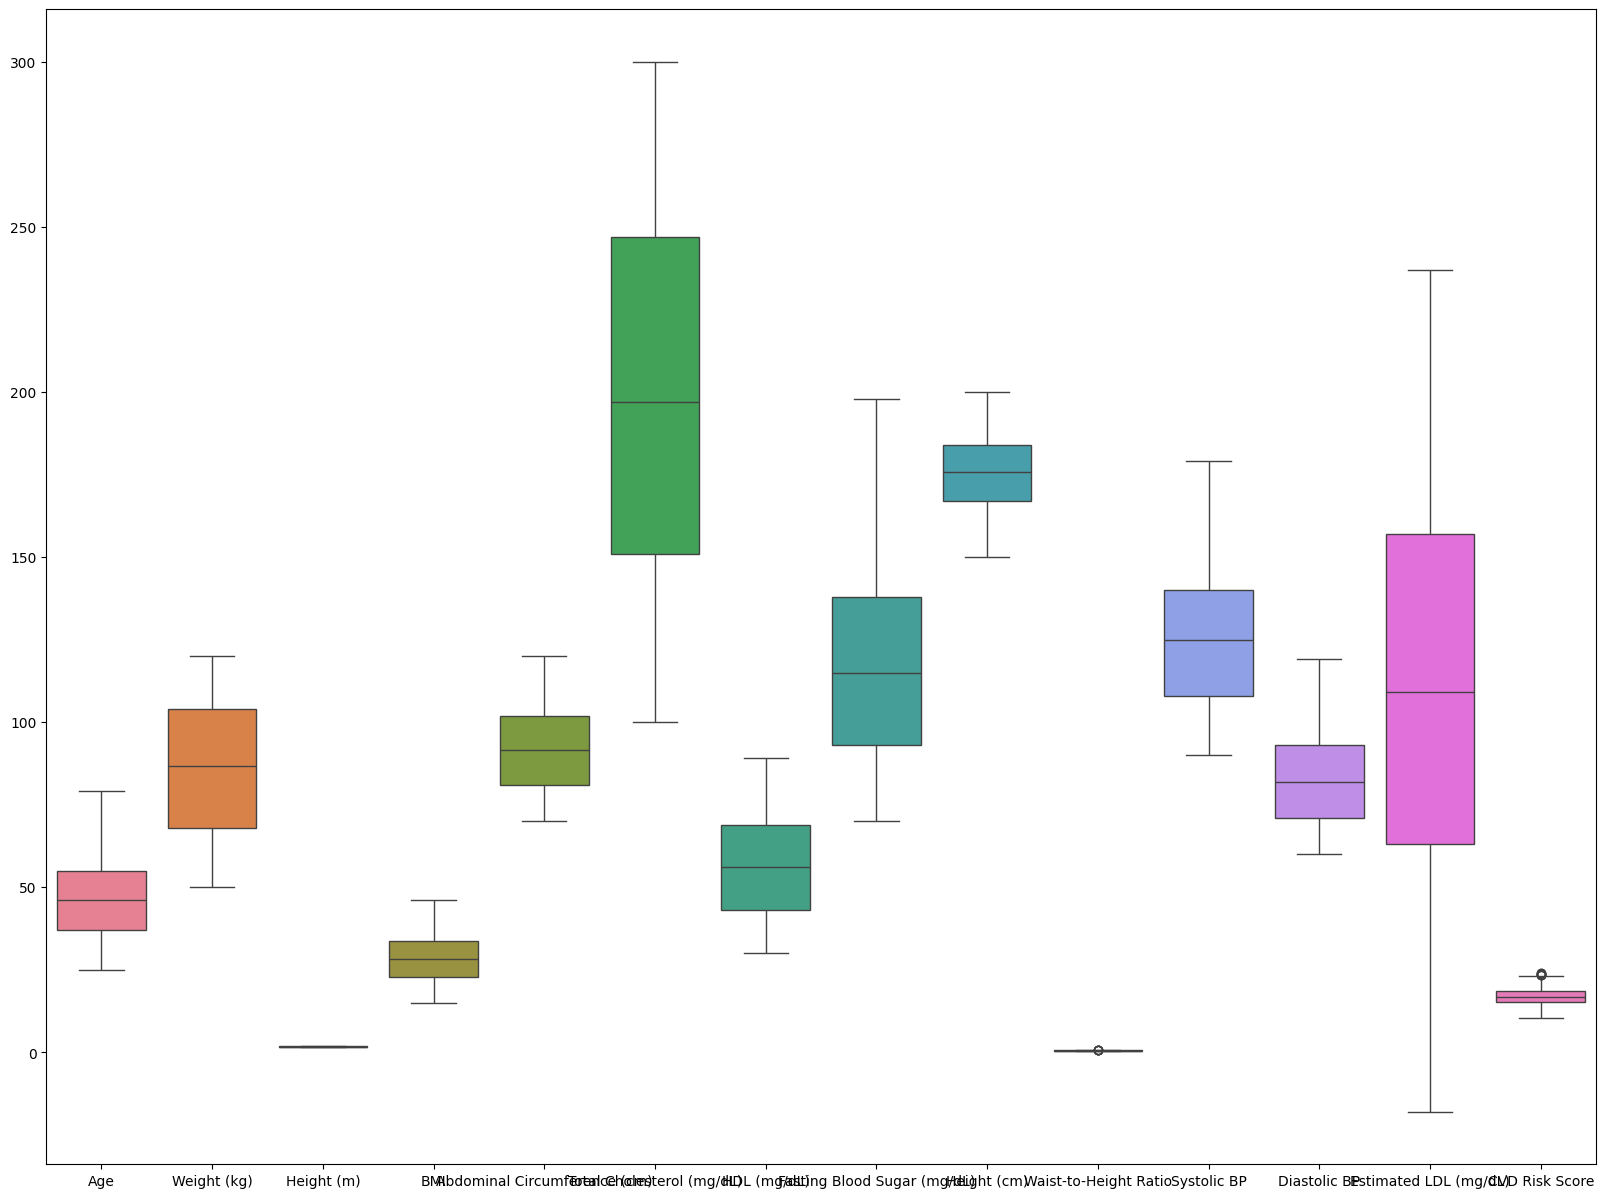

In [6]:
plt.figure(figsize=(20,15))
sns.boxplot(df)

Sex
F    773
M    756
Name: count, dtype: int64


/tmp/ipykernel_17/2181302100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=c.index,y=c.values,palette='viridis')


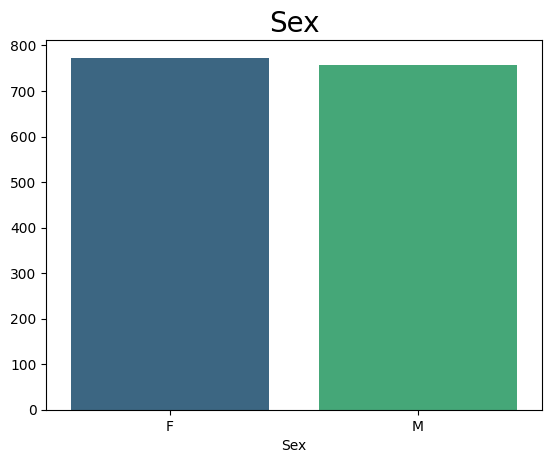

Smoking Status
Y    789
N    740
Name: count, dtype: int64


/tmp/ipykernel_17/2181302100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=c.index,y=c.values,palette='viridis')


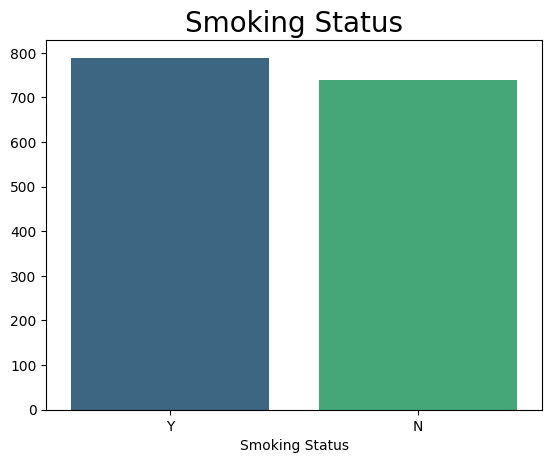

Diabetes Status
Y    777
N    752
Name: count, dtype: int64


/tmp/ipykernel_17/2181302100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=c.index,y=c.values,palette='viridis')


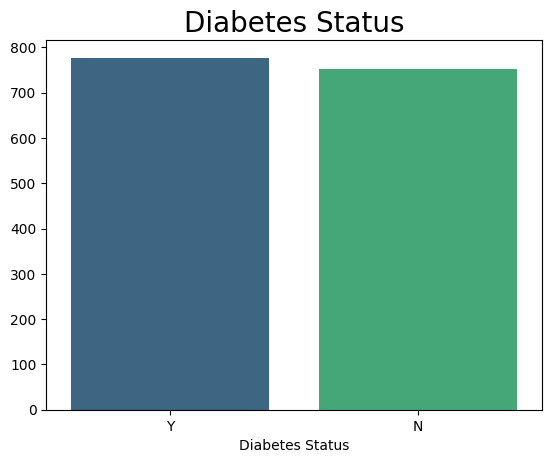

Physical Activity Level
High        521
Moderate    512
Low         496
Name: count, dtype: int64


/tmp/ipykernel_17/2181302100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=c.index,y=c.values,palette='viridis')


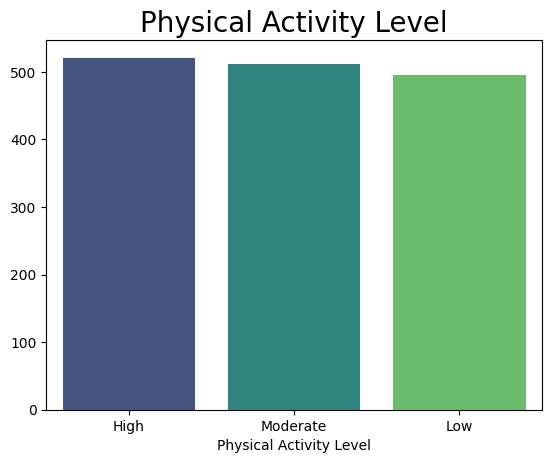

Family History of CVD
N    780
Y    749
Name: count, dtype: int64


/tmp/ipykernel_17/2181302100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=c.index,y=c.values,palette='viridis')


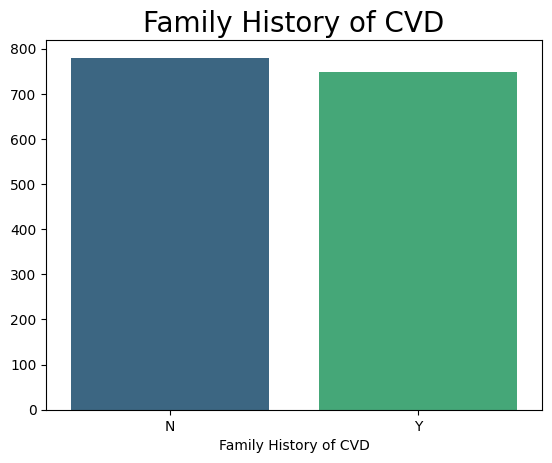

Blood Pressure Category
Hypertension Stage 2    632
Hypertension Stage 1    497
Normal                  300
Elevated                100
Name: count, dtype: int64


/tmp/ipykernel_17/2181302100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=c.index,y=c.values,palette='viridis')


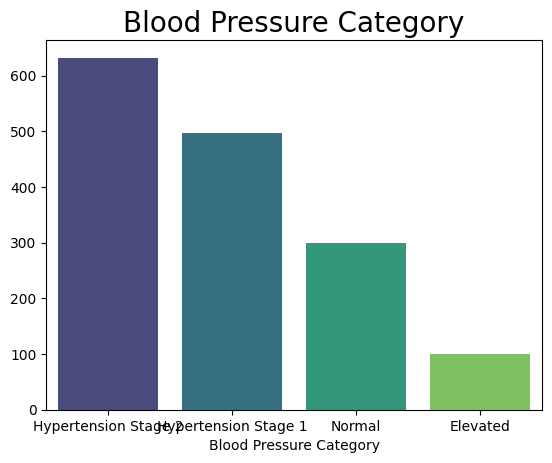

CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64


/tmp/ipykernel_17/2181302100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=c.index,y=c.values,palette='viridis')


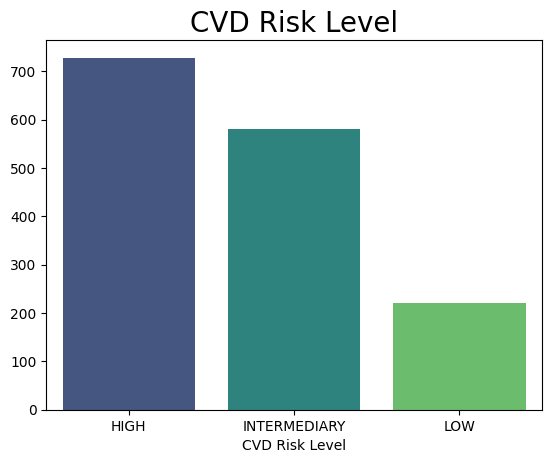

In [7]:
arr=['Sex','Smoking Status', 'Diabetes Status','Physical Activity Level', 'Family History of CVD',
       'Blood Pressure Category','CVD Risk Level']
for i in arr:
    c=df[i].value_counts()
    print(c)
    sns.barplot(x=c.index,y=c.values,palette='viridis')
    plt.title(i,size=20)
    plt.show()

In [8]:
df['CVD Risk Level']=df['CVD Risk Level'].map({'HIGH':2,'INTERMEDIARY':1,'LOW':0})

<Axes: >

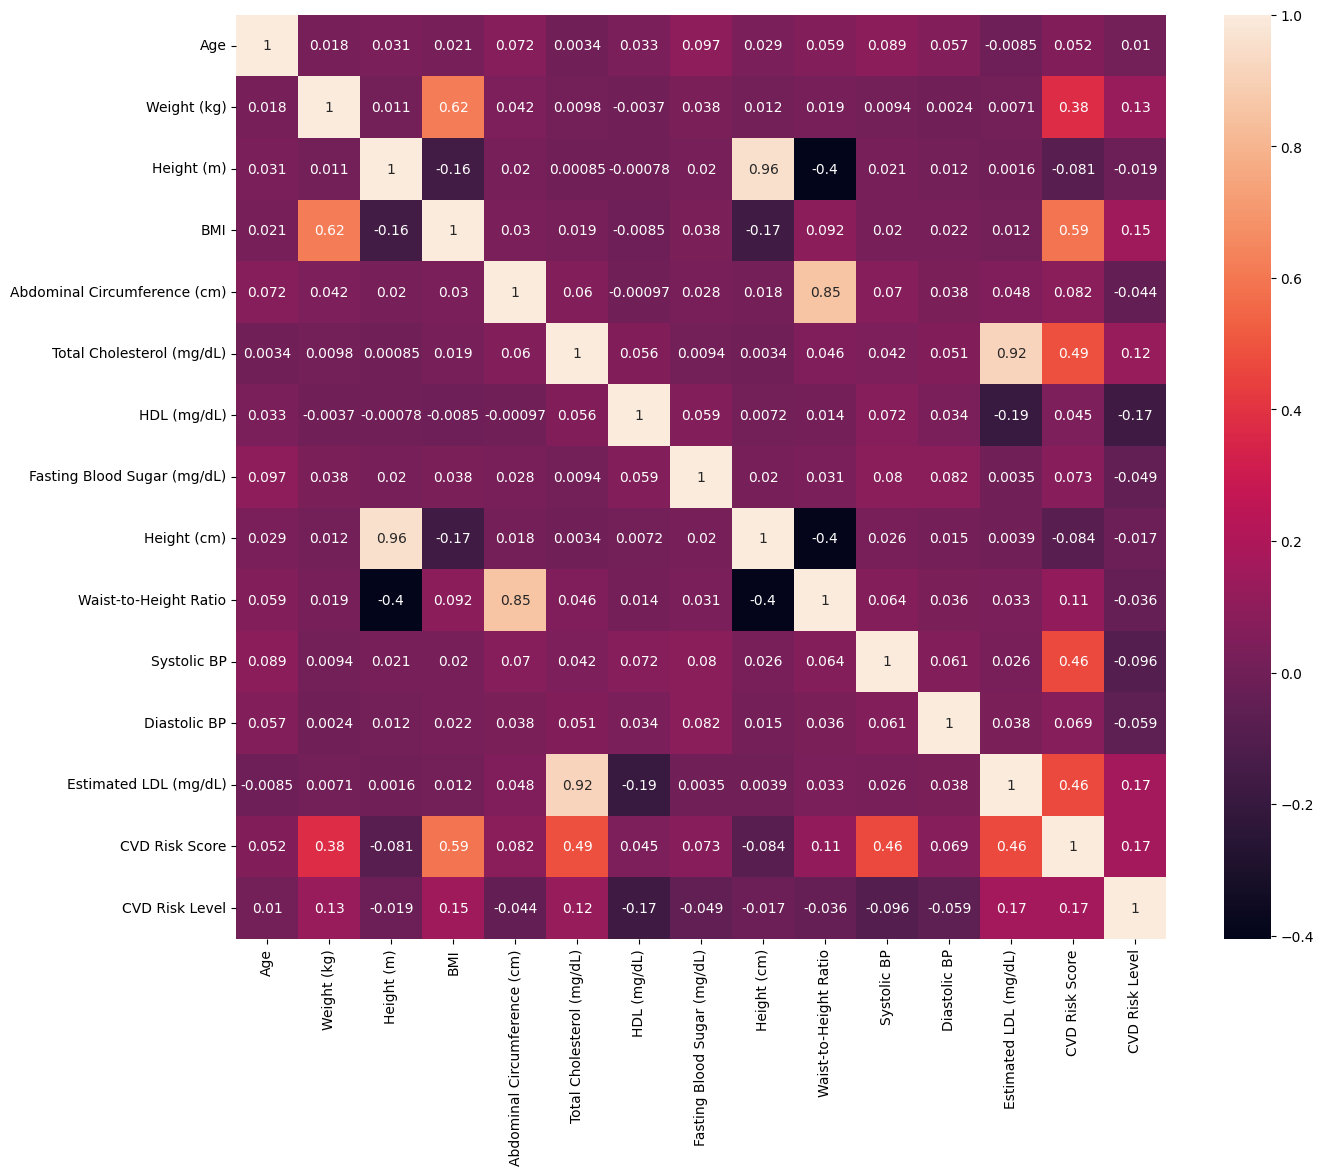

In [9]:
arr=['Age','Weight (kg)','Height (m)','BMI','Abdominal Circumference (cm)','Total Cholesterol (mg/dL)','HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)','Height (cm)','Waist-to-Height Ratio','Systolic BP',
     'Diastolic BP','Estimated LDL (mg/dL)','CVD Risk Score','CVD Risk Level']
cor=df[arr].corr()
plt.figure(figsize=(15,12))
sns.heatmap(cor,annot=True)

In [10]:
df=df.drop(columns=['Height (m)'])

In [11]:
df.shape

(1529, 21)

In [12]:
df['Smoking Status']=df['Smoking Status'].map({'Y':1,'N':0}) 
df['Diabetes Status']=df['Diabetes Status'].map({'Y':1,'N':0}) 
df['Physical Activity Level']=df['Physical Activity Level'].map({'Low':0,'Moderate':1,'High':2})
df['Family History of CVD']=df['Family History of CVD'].map({'Y':1,'N':0}) 

In [13]:
df.head()

,Sex,Age,Weight (kg),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1000,23.6,86.2,125/79,248.0,78.0,111.0,0,...,0,0,171.000,0.504,125.0,79.0,Elevated,140.0,17.93,1
1,F,55.0,118.7000,41.6,82.5,139/70,162.0,50.0,135.0,1,...,2,1,169.000,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,2
2,M,46.0,86.6145,26.9,106.7,104/77,103.0,73.0,114.0,0,...,2,1,183.000,0.583,104.0,77.0,Normal,0.0,12.64,1
3,M,44.0,108.3000,33.4,96.6,140/83,134.0,46.0,91.0,0,...,2,1,175.694,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,1
4,F,32.0,99.5000,28.8,102.7,144/83,146.0,64.0,141.0,1,...,2,0,186.000,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,1


# Regresssion

In [14]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features & target
X = df.drop(columns=['CVD Risk Level','CVD Risk Score','Blood Pressure (mmHg)'], axis=1)
y = df['CVD Risk Score']

# Categorical columns
cat_features = [
    'Sex',
    'Smoking Status',
    'Diabetes Status',
    'Physical Activity Level',
    'Family History of CVD',
    'Blood Pressure Category'
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = CatBoostRegressor(
    iterations=6000,
    depth=7,
    learning_rate=0.0125,

    loss_function='RMSE',
    eval_metric='RMSE',

    l2_leaf_reg=8,
    random_strength=3,
    bagging_temperature=0.8,
    border_count=128,

    od_type='Iter',
    od_wait=300,

    random_seed=123,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

y_pred = model.predict(X_test)

# Regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

0:	learn: 2.2978640	test: 2.5516284	best: 2.5516284 (0)	total: 57ms	remaining: 5m 42s
100:	learn: 1.4092354	test: 1.6069141	best: 1.6069141 (100)	total: 313ms	remaining: 18.3s
200:	learn: 0.9946564	test: 1.1515830	best: 1.1515830 (200)	total: 570ms	remaining: 16.4s
300:	learn: 0.7988021	test: 0.9204009	best: 0.9204009 (300)	total: 830ms	remaining: 15.7s
400:	learn: 0.6975459	test: 0.8014830	best: 0.8014830 (400)	total: 1.08s	remaining: 15s
500:	learn: 0.6364681	test: 0.7308419	best: 0.7308419 (500)	total: 1.34s	remaining: 14.7s
600:	learn: 0.5911239	test: 0.6846762	best: 0.6846762 (600)	total: 1.62s	remaining: 14.5s
700:	learn: 0.5543364	test: 0.6544494	best: 0.6544494 (700)	total: 1.92s	remaining: 14.5s
800:	learn: 0.5218340	test: 0.6331319	best: 0.6331319 (800)	total: 2.24s	remaining: 14.5s
900:	learn: 0.4967643	test: 0.6227343	best: 0.6227343 (900)	total: 2.54s	remaining: 14.4s
1000:	learn: 0.4780551	test: 0.6172175	best: 0.6172175 (1000)	total: 2.92s	remaining: 14.6s
1100:	learn: 0

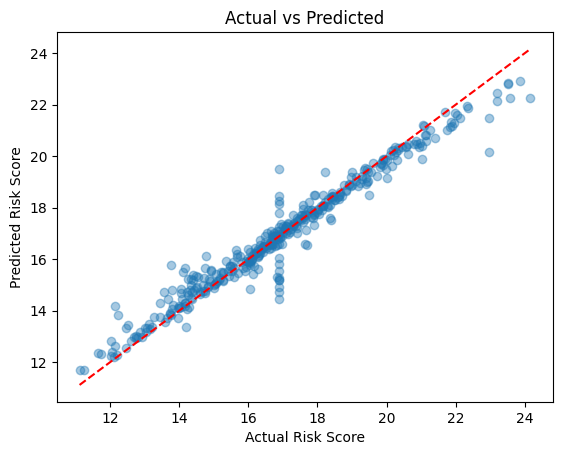

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()


In [16]:

imp = model.get_feature_importance()
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': imp
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))


                      Feature  Importance
3                         BMI   26.450194
9             Diabetes Status   19.912527
14                Systolic BP   17.640258
5   Total Cholesterol (mg/dL)   13.057210
17      Estimated LDL (mg/dL)   10.061576
2                 Weight (kg)    3.359317
16    Blood Pressure Category    2.352475
6                 HDL (mg/dL)    1.378081
12                Height (cm)    1.059571
13      Waist-to-Height Ratio    0.929355


# Classification

In [17]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features & target
X=df.drop(columns=['CVD Risk Level','CVD Risk Score','Blood Pressure (mmHg)'],axis=1)

y=df['CVD Risk Level']

# Identify categorical columns by name
cat_features = [
 'Sex',
 'Smoking Status',
 'Diabetes Status',
 'Physical Activity Level',
 'Family History of CVD',
 'Blood Pressure Category'
]


X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.25, random_state=42, stratify=y
)

model = CatBoostClassifier(
    iterations=6000,
    depth=7,
    learning_rate=0.0125,

    loss_function='MultiClass',
    eval_metric='TotalF1',
    auto_class_weights='Balanced',

    boosting_type='Ordered',
    grow_policy='SymmetricTree',

    l2_leaf_reg=8,
    random_strength=3,
    bagging_temperature=0.8,

    border_count=128,

    od_type='Iter',
    od_wait=300,

    random_seed=123,
    verbose=100,
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)


y_pred=model.predict(X_test)

print(classification_report(y_test,y_pred))

0:	learn: 0.4812843	test: 0.4127330	best: 0.4127330 (0)	total: 32.9ms	remaining: 3m 17s
100:	learn: 0.6209385	test: 0.5100131	best: 0.5242811 (87)	total: 1.44s	remaining: 1m 24s
200:	learn: 0.6438590	test: 0.5472563	best: 0.5472563 (199)	total: 2.82s	remaining: 1m 21s
300:	learn: 0.6579746	test: 0.5558999	best: 0.5558999 (298)	total: 3.98s	remaining: 1m 15s
400:	learn: 0.6645348	test: 0.5695530	best: 0.5772838 (383)	total: 5.29s	remaining: 1m 13s
500:	learn: 0.6766903	test: 0.5679496	best: 0.5790104 (409)	total: 6.59s	remaining: 1m 12s
600:	learn: 0.6911528	test: 0.5802827	best: 0.5808069 (537)	total: 7.89s	remaining: 1m 10s
700:	learn: 0.7087643	test: 0.5786651	best: 0.5825530 (612)	total: 9.26s	remaining: 1m 9s
800:	learn: 0.7469254	test: 0.5837977	best: 0.5932105 (793)	total: 11.4s	remaining: 1m 14s
900:	learn: 0.7791874	test: 0.6105034	best: 0.6105034 (900)	total: 14.1s	remaining: 1m 19s
1000:	learn: 0.7972280	test: 0.6080994	best: 0.6121510 (909)	total: 16.8s	remaining: 1m 23s
110